# HPP Chapter 1 — Understanding Performant Python
### Phase 01 · High Performance Python Ch 1 · Complete Reference Notebook

> *"High performance programming can be thought of as the act of minimizing
> these operations either by reducing the overhead or by finding a more
> suitable algorithm."* — High Performance Python

This notebook is a **standalone reference** for Chapter 1.
Read the actual chapter first. Return here to study, practice, and review.

**How to use:**
- Chapter content is covered faithfully and in order — Parts 1–7
- ML/DL extensions come **after** the chapter foundation — Parts 8–11
- Every concept that can be measured has a runnable experiment

---

**Sections**

| # | Chapter Foundation | # | ML / DL Extension |
|---|---|---|---|
| 1 | The fundamental computer system | 8 | Python object tax — dtype impact on ML data |
| 2 | Computing units — IPC, SIMD, GIL, Amdahl | 9 | NumPy releases the GIL — threads for numpy work |
| 3 | Memory units — the hierarchy | 10 | Row-major vs column-major for batch processing |
| 4 | Communications layers — buses and bandwidth | 11 | Batch size × vectorization — the ML sweet spot |
| 5 | Putting it together — idealized vs Python VM | | |
| 6 | So why use Python? | | |
| 7 | How to be a highly performant programmer | | |



---
# Part 1 — The Fundamental Computer System


## Three components — every performance problem maps to one of them

The underlying components of any computer simplify to three parts:

```
┌──────────────────────────────────────────────────────────────────┐
│                                                                  │
│  COMPUTING UNITS              MEMORY UNITS                       │
│  ──────────────               ────────────                       │
│  CPU  — general purpose       Registers       (bytes,   ~0.3ns)  │
│  GPU  — massively parallel    L1/L2 cache     (KB–MB,   ~1–4ns)  │
│                               RAM             (GB,      ~100ns)  │
│                               SSD             (TB,      ~100μs)  │
│  COMMUNICATIONS               Spinning HDD    (TB,      ~10ms)   │
│  ───────────────                                                  │
│  Frontside bus   CPU ↔ L1/L2  (fast, on-die)                     │
│  PCIe bus        CPU ↔ GPU    (~16 GB/s — 3× slower than RAM)    │
│  Network         node ↔ node  (slowest, highest latency)         │
│                                                                  │
└──────────────────────────────────────────────────────────────────┘
```

**Each unit has two defining properties:**
- **Computing unit:** operations per second × IPC
- **Memory unit:** capacity + read/write speed
- **Communications:** bandwidth (how much) + latency (how long to start)

**The optimization discipline:**
1. Identify which component is the bottleneck
2. Reduce the work that component must do
3. Or move the work to a faster component

> *"By understanding the best way bits can be moved in the real hardware
> and the ways Python's abstractions force your bits to move, you can
> make progress toward writing high performance programs."* — HPP



---
# Part 2 — Computing Units: IPC, Clock Speed, Vectorization, GIL, Amdahl's Law


## The two key properties

| Property | Measured by | Trend since ~2004 |
|---|---|---|
| **IPC** — instructions per cycle | CPU microarchitecture | Slow improvement |
| **Clock speed** | GHz | Effectively stalled (physics wall) |

`throughput = IPC × clock_speed`

Since clock speed stalled, chip designers compensated with:
- **Hyperthreading** — 2 virtual CPUs share 1 physical core (~30% gain on mixed workloads)
- **Out-of-order execution** — CPU runs independent instructions while others wait on memory
- **Multicore** — more CPUs per die; total throughput increases, single-thread speed flat
- **SIMD (vectorization)** — one instruction operates on multiple data values simultaneously

## Vectorization (SIMD)

```
Scalar (Python loop):
    for i in range(N): result[i] = a[i] + b[i]
    └── N separate add instructions, one element per clock

SIMD (NumPy AVX2):
    result = a + b
    └── processes 8 float32 values per clock tick (AVX2 = 256-bit wide)
```

Python loops cannot be auto-vectorized by the interpreter.
NumPy calls BLAS/LAPACK C routines that use SIMD intrinsics automatically.
This single gap accounts for 50–200× speed differences between `sum(list)` and `np.sum(arr)`.

## The GIL — Python's multicore problem

The **Global Interpreter Lock** ensures only one thread executes Python bytecode
at a time, regardless of how many physical cores exist.

```
Thread A: ──[acquire GIL]──[bytecode]──[release]──
Thread B: ──[acquire GIL]──[bytecode]──[release]──
```

**Consequence:** adding threads to CPU-bound pure Python work gives no speedup —
sometimes it's slower due to GIL contention overhead.

**Workarounds the book covers:**
- `multiprocessing` — each process has its own GIL and memory space (Ch 9)
- NumPy / Cython — C extensions can release the GIL during execution (Ch 6, 7)
- `async/await` — for I/O-bound work, bypasses GIL via cooperative concurrency (Ch 8)

## Amdahl's Law — the ceiling on parallel speedup

```
Speedup(N) = 1 / ( (1 - p) + p/N )
```

`p` = fraction of the program that is parallelizable.
The serial fraction `(1 - p)` sets a hard ceiling that no amount of hardware can beat.

**Example:** if 90% of a task is parallelizable (`p = 0.9`), then 10% is serial,
and the theoretical maximum speedup is 10×, regardless of whether you use 8, 64, or 1000 cores.
This is why blindly increasing `multiprocessing` worker count hits diminishing returns quickly.


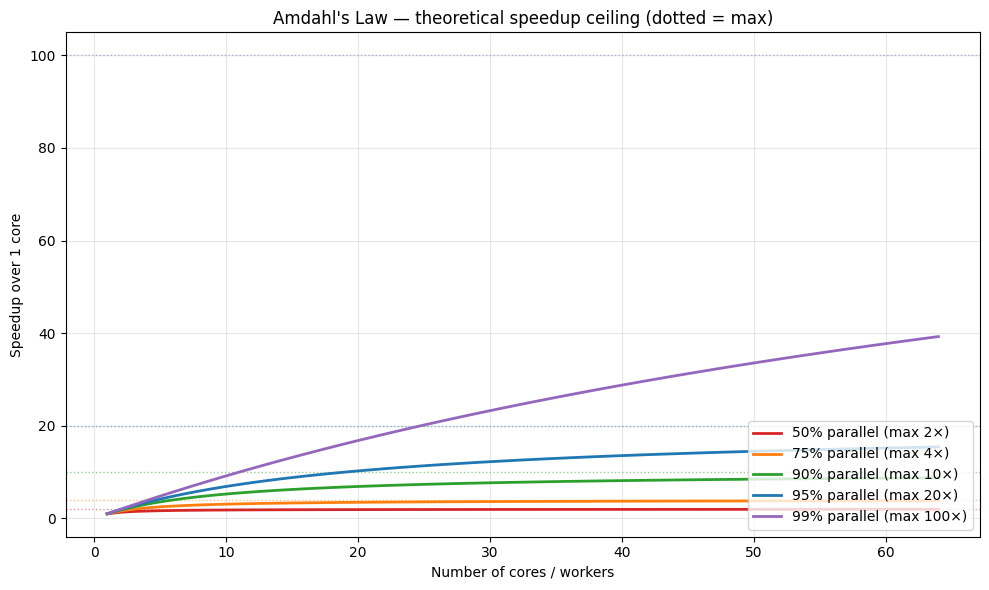

Parallel fraction (p)  Speedup @ 8  Speedup @ 32   Theoretical max
----------------------------------------------------------------
        50% parallel         1.8×           1.9×                2×
        75% parallel         2.9×           3.7×                4×
        90% parallel         4.7×           7.8×               10×
        95% parallel         5.9×          12.5×               20×
        99% parallel         7.5×          24.4×              100×

Interpretation: Even with 99% parallel (p=0.99), 1% serial caps speedup at 100×.
The dotted lines show each curve's hard ceiling — you cannot exceed this regardless of cores.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

def amdahl_speedup(p, n):
    return 1 / ((1 - p) + p / n)

cores  = np.arange(1, 65)
# p = parallel fraction (0.90 = 90% parallel, 10% serial → max speedup 10×)
fracs  = [0.50, 0.75, 0.90, 0.95, 0.99]
labels = ["50% parallel (max 2×)", "75% parallel (max 4×)", 
          "90% parallel (max 10×)", "95% parallel (max 20×)", 
          "99% parallel (max 100×)"]
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]

fig, ax = plt.subplots(figsize=(10, 6))
for p, label, color in zip(fracs, labels, colors):
    ax.plot(cores, [amdahl_speedup(p, n) for n in cores],
            label=label, color=color, linewidth=2)
    ceiling = 1 / (1 - p)
    ax.axhline(ceiling, color=color, linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel("Number of cores / workers")
ax.set_ylabel("Speedup over 1 core")
ax.set_title("Amdahl's Law — theoretical speedup ceiling (dotted = max)")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Parallel fraction (p)':>20}  {'Speedup @ 8':>10}  {'Speedup @ 32':>12}  {'Theoretical max':>16}")
print("-" * 64)
for p, label in zip(fracs, labels):
    print(f"{label.split(' (max')[0]:>20}  {amdahl_speedup(p,8):>10.1f}×  "
          f"{amdahl_speedup(p,32):>12.1f}×  {1/(1-p):>15.0f}×")
print()
print("Interpretation: Even with 99% parallel (p=0.99), 1% serial caps speedup at 100×.")
print("The dotted lines show each curve's hard ceiling — you cannot exceed this regardless of cores.")

In [2]:
import time
import threading
import multiprocessing

def cpu_bound(n):
    total = 0
    for i in range(n):
        total += i * i
    return total

N = 4_000_000

# Serial baseline
t0 = time.perf_counter()
cpu_bound(N); cpu_bound(N)
t_serial = time.perf_counter() - t0

# 2 threads — GIL serializes Python bytecode
t0 = time.perf_counter()
threads = [threading.Thread(target=cpu_bound, args=(N,)) for _ in range(2)]
for t in threads: t.start()
for t in threads: t.join()
t_threads = time.perf_counter() - t0

# 2 processes — each has its own GIL
t0 = time.perf_counter()
procs = [multiprocessing.Process(target=cpu_bound, args=(N,)) for _ in range(2)]
for p in procs: p.start()
for p in procs: p.join()
t_procs = time.perf_counter() - t0

print(f"Serial (2 runs) : {t_serial:.3f}s  (baseline)")
print(f"2 threads       : {t_threads:.3f}s  ({t_threads/t_serial:.2f}×)  ← GIL: no speedup")
print(f"2 processes     : {t_procs:.3f}s  ({t_procs/t_serial:.2f}×)  ← true parallelism")
print()
print("Threads look concurrent but GIL serializes Python bytecode execution.")
print("Processes escape the GIL — each interpreter is independent.")
print("Cost: ~100ms process startup + inter-process communication overhead.")

Serial (2 runs) : 0.635s  (baseline)
2 threads       : 0.537s  (0.85×)  ← GIL: no speedup
2 processes     : 0.330s  (0.52×)  ← true parallelism

Threads look concurrent but GIL serializes Python bytecode execution.
Processes escape the GIL — each interpreter is independent.
Cost: ~100ms process startup + inter-process communication overhead.



---
# Part 3 — Memory Units: The Hierarchy


## Speed and capacity are inversely proportional

| Memory type | Capacity | Read latency | Bandwidth | Notes |
|---|---|---|---|---|
| CPU registers | bytes | ~0.3 ns | — | loop variables |
| L1/L2 cache | KB–MB | ~1–4 ns | ~1 TB/s | must go through here to reach CPU |
| RAM | 16–512 GB | ~100 ns | ~50 GB/s | application data |
| SSD (NVMe) | TB | ~100 μs | ~3 GB/s | dataset storage |
| Spinning HDD | TB | ~10 ms | ~200 MB/s | degraded by random access |

**The key rule:** read/write speed and capacity trade off against each other.
Optimizing memory access means deciding what data goes where, how it's laid out,
and how many times it moves.

## Sequential reads vs random reads

Most memory units perform **much better on sequential reads** — reading
contiguous blocks — than on random access patterns.

> *"If the data in these memory units is thought of as pages in a large book,
> most memory units have better read/write speeds when going through the book
> page by page rather than constantly flipping from one random page to another."*
> — HPP

This is why:
- An array of packed floats is faster to traverse than a list of Python float objects
- Shuffling a dataset before batching (in-memory) is cheaper than random disk seeks
- NumPy arrays (contiguous C arrays) outperform Python lists for iteration

## The tiered system uses asynchronous I/O and prefetching

Modern systems move data up the hierarchy in advance:
- The CPU prefetches cache lines before they're needed
- SSDs read ahead when access is sequential
- `DataLoader` prefetches the next batch while the GPU processes the current one

When a tier runs dry, the computation stalls and waits. That stall is the bottleneck.


In [3]:
import random
import timeit
import array as arr
import numpy as np

SIZE = 500_000

data     = list(range(SIZE))
data_np  = np.arange(SIZE, dtype=np.int64)
data_arr = arr.array('l', range(SIZE))

idx_seq  = list(range(SIZE))
idx_rand = list(range(SIZE))
random.shuffle(idx_rand)

# ── 1. Sequential vs random indexing ─────────────────────────────
t_seq  = timeit.timeit(lambda: sum(data[i] for i in idx_seq),  number=5) / 5
t_rand = timeit.timeit(lambda: sum(data[i] for i in idx_rand), number=5) / 5

print("=== Sequential vs Random read ===")
print(f"  Sequential : {t_seq*1000:.1f}ms")
print(f"  Random     : {t_rand*1000:.1f}ms  ({t_rand/t_seq:.1f}× slower)")
print()

# ── 2. Python list vs array.array vs numpy — storage layout ───────
t_list = timeit.timeit(lambda: sum(data),         number=10) / 10
t_arr  = timeit.timeit(lambda: sum(data_arr),     number=10) / 10
t_np   = timeit.timeit(lambda: data_np.sum(),     number=500) / 500

print("=== Storage layout — traversal cost ===")
print(f"  list (pointer array)    : {t_list*1000:.2f}ms  — each elem is a heap object")
print(f"  array.array (C doubles) : {t_arr*1000:.2f}ms  — contiguous, no object overhead")
print(f"  np.ndarray (vectorized) : {t_np*1000:.3f}ms  — SIMD C loop")
print()
print("list: each element access = pointer dereference = potential cache miss")
print("array.array/numpy: elements packed in memory → prefetcher works efficiently")

=== Sequential vs Random read ===
  Sequential : 17.2ms
  Random     : 167.4ms  (9.7× slower)

=== Storage layout — traversal cost ===
  list (pointer array)    : 4.11ms  — each elem is a heap object
  array.array (C doubles) : 9.38ms  — contiguous, no object overhead
  np.ndarray (vectorized) : 0.188ms  — SIMD C loop

list: each element access = pointer dereference = potential cache miss
array.array/numpy: elements packed in memory → prefetcher works efficiently



---
# Part 4 — Communications Layers: Buses and Bandwidth


## Everything communicates through a bus

A **bus** is the physical pathway that moves data between components.
Its two defining properties:

| Property | What it controls |
|---|---|
| **Bus width** | How many bits move in one transfer |
| **Bus frequency** | How many transfers per second |

`bandwidth = bus_width × bus_frequency`

## The buses that matter

**Frontside bus (CPU ↔ L1/L2 cache)**
- Fastest bus in the system — directly connects CPU to cache
- Data going to the CPU must pass through here
- L1/L2 exist because queuing data for computation in large chunks on the slow RAM bus,
  then serving it at very high speed from cache, beats reading from RAM per-element

**PCIe bus (CPU ↔ GPU)**
- GPU is a peripheral — it connects via PCIe, not the frontside bus
- ~16 GB/s (PCIe 4.0 ×16) vs ~50 GB/s for RAM
- Sending a tensor from CPU RAM to GPU VRAM crosses this 3× slower connection
- The GPU's on-device memory bandwidth (~2 TB/s for A100) dwarfs PCIe —
  so once data is on the GPU, operations are fast; getting it there is the cost

**Network (node ↔ node)**
- Limited to several dozen megabits/second (vs gigabits on internal buses)
- High latency (~ms round-trip vs ~ns for cache)
- In distributed training, gradient synchronization crosses the network —
  this is why gradient compression and allreduce algorithms matter

## Bus width and physical layout

Bus width has literal physical meaning: the number of wires on the motherboard.
Chips placed closer together can have shorter wires → faster transfers.
This is why CPU caches are literally on the same die as the CPU cores.

## The L1/L2 cache insight

> *"Many of the benefits of the L1/L2 cache are attributable to the faster bus.
> Being able to queue up data necessary for computation in large chunks on a slow bus
> (from RAM to cache) and then having it available at very fast speeds from the cache
> enables the CPU to do more calculations without waiting."* — HPP

The performance implication: **keep data local**. Move it to the right tier once.
The concept of "heavy data" — the time and energy to move data around —
is something we always want to minimize.


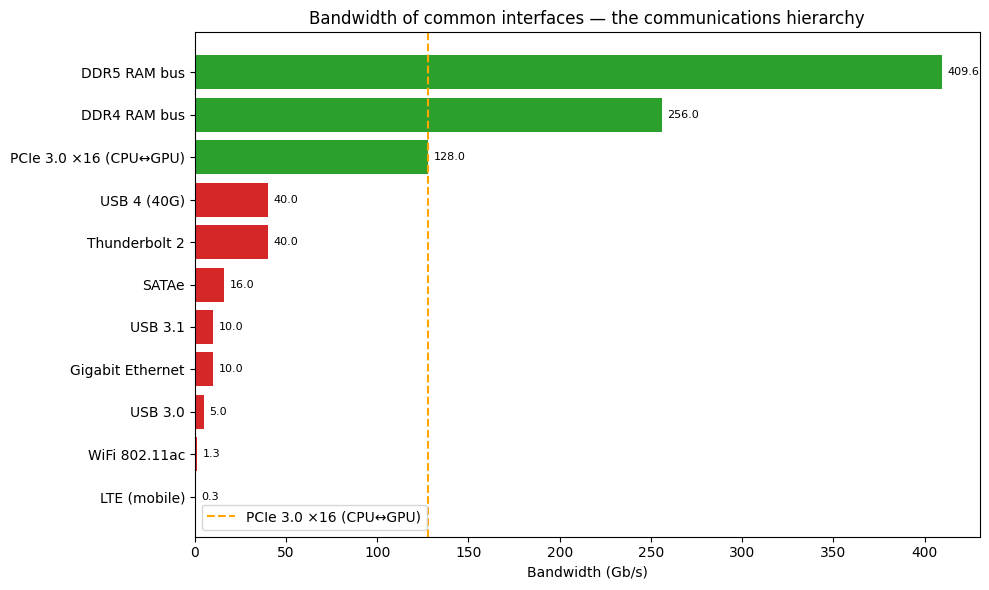

Key ratios:
  RAM / PCIe (CPU↔GPU) ratio : 2.0× — RAM to CPU is 2× faster than CPU to GPU
  PCIe / GigE ratio          : 13× — internal bus >> network

Production consequence:
  .to(device) is expensive — cross the PCIe bus as few times as possible.
  pin_memory=True in DataLoader: uses page-locked RAM for faster PCIe DMA.
  Distributed training: gradients cross network — 13× slower than local PCIe.


In [4]:
# Bandwidth comparison — the numbers from the chapter put in perspective
bandwidths = {
    "LTE (mobile)"        : 0.326,
    "WiFi 802.11ac"       : 1.3,
    "USB 3.0"             : 5.0,
    "Gigabit Ethernet"    : 10.0,
    "USB 3.1"             : 10.0,
    "SATAe"               : 16.0,
    "Thunderbolt 2"       : 40.0,
    "USB 4 (40G)"         : 40.0,
    "PCIe 3.0 ×16 (CPU↔GPU)": 128.0,
    "DDR4 RAM bus"        : 256.0,
    "DDR5 RAM bus"        : 409.6,
}

import matplotlib.pyplot as plt

names = list(bandwidths.keys())
vals  = list(bandwidths.values())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, vals, color=['#d62728' if v < 50 else '#2ca02c' for v in vals])
ax.set_xlabel("Bandwidth (Gb/s)")
ax.set_title("Bandwidth of common interfaces — the communications hierarchy")
ax.axvline(128, color='orange', linestyle='--', linewidth=1.5, label='PCIe 3.0 ×16 (CPU↔GPU)')
ax.legend()
for bar, val in zip(bars, vals):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Key ratios:")
pcie   = bandwidths["PCIe 3.0 ×16 (CPU↔GPU)"]
ddr4   = bandwidths["DDR4 RAM bus"]
gige   = bandwidths["Gigabit Ethernet"]
print(f"  RAM / PCIe (CPU↔GPU) ratio : {ddr4/pcie:.1f}× — RAM to CPU is 2× faster than CPU to GPU")
print(f"  PCIe / GigE ratio          : {pcie/gige:.0f}× — internal bus >> network")
print()
print("Production consequence:")
print("  .to(device) is expensive — cross the PCIe bus as few times as possible.")
print("  pin_memory=True in DataLoader: uses page-locked RAM for faster PCIe DMA.")
print("  Distributed training: gradients cross network — 13× slower than local PCIe.")


---
# Part 5 — Putting It Together: Idealized Computing vs the Python VM


## The chapter's central example: `check_prime`

```python
def check_prime(number):
    sqrt_number = math.sqrt(number)
    for i in range(2, int(sqrt_number) + 1):
        if (number / i).is_integer():
            return False
    return True
```

### What idealized computing would do

1. Load `number` into L1 cache once — never re-fetch from RAM
2. **Vectorize** the loop: check 8 values of `i` per clock cycle (SIMD)
3. Early-terminate on the first factor found

### What Python's VM actually does per loop iteration

```
LOAD_FAST   i                ← fetch Python int object pointer from locals dict
LOAD_FAST   number           ← fetch Python int object pointer from locals dict
BINARY_OP   /                ← call number.__truediv__(i), dynamic dispatch
LOAD_ATTR   is_integer       ← attribute lookup on the float result object
CALL        is_integer()     ← Python function call overhead
POP_JUMP_IF_FALSE            ← conditional branch
```

**Six bytecode instructions per iteration.** Each carries:
- **Dynamic type dispatch**: Python doesn't know `number` is an `int` at compile time —
  it checks at runtime every iteration
- **Object allocation**: intermediate results are Python objects on the heap
- **Memory fragmentation**: `number` and `i` are not packed in a cache line —
  they're scattered across the heap wherever the GC placed them
- **No vectorization**: Python's abstraction prevents the CPU from batching iterations

### The three killers Python's VM introduces

1. **No SIMD**: Python loops process one element at a time
2. **Dynamic types**: every operation requires a runtime type lookup
3. **Memory fragmentation**: GC-managed objects scatter data across the heap,
   breaking the L1/L2 cache locality that vectorized code relies on

### The fix: delegate to C

NumPy replaces the Python loop with a single C function call.
The C code uses SIMD, is type-stable (no dynamic dispatch), and operates
on contiguous memory — all three killers eliminated at once.


In [5]:
import math
import timeit
import numpy as np

# ── Book version: pure Python ────────────────────────────────────
def check_prime_python(number):
    sqrt_number = math.sqrt(number)
    for i in range(2, int(sqrt_number) + 1):
        if (number / i).is_integer():
            return False
    return True

# ── NumPy: one vectorized C call replaces the loop ────────────────
def check_prime_numpy(number):
    i = np.arange(2, int(math.sqrt(number)) + 1)
    return not np.any(number % i == 0)

# ── Correctness ───────────────────────────────────────────────────
cases = [(10_000_000, False), (10_000_019, True), (982_451_653, True)]
print("Correctness check:")
for n, expected in cases:
    r1, r2 = check_prime_python(n), check_prime_numpy(n)
    ok = "✓" if r1 == r2 == expected else "✗"
    print(f"  {ok}  {n:>12,}  python={r1}  numpy={r2}  expected={expected}")

print()

# ── Benchmark on large prime (worst case — loop runs to completion) ─
target = 982_451_653
N      = 100
t_py   = timeit.timeit(lambda: check_prime_python(target), number=N) / N
t_np   = timeit.timeit(lambda: check_prime_numpy(target),  number=N) / N

print(f"Pure Python : {t_py*1000:.2f}ms")
print(f"NumPy       : {t_np*1000:.2f}ms  ({t_py/t_np:.1f}× faster)")
print()
print("Why NumPy wins on the large prime (worst case):")
print("  Python: ~31,000 loop iterations, each with 6 bytecode dispatches")
print("  NumPy : one np.arange() + one np.any() — two C-level calls")
print()
print("Why Python can win on a small composite:")

small_composite = 10_000_000   # divisible by 2 — Python exits at i=2
t_py2 = timeit.timeit(lambda: check_prime_python(small_composite), number=N) / N
t_np2 = timeit.timeit(lambda: check_prime_numpy(small_composite),  number=N) / N
print(f"  {small_composite:,}: Python={t_py2*1e6:.1f}μs  NumPy={t_np2*1e6:.1f}μs")
print("  Python early-exits after 1 check; NumPy always allocates the full arange array.")

Correctness check:
  ✓    10,000,000  python=False  numpy=False  expected=False
  ✓    10,000,019  python=True  numpy=True  expected=True
  ✓   982,451,653  python=True  numpy=True  expected=True

Pure Python : 3.51ms
NumPy       : 0.37ms  (9.4× faster)

Why NumPy wins on the large prime (worst case):
  Python: ~31,000 loop iterations, each with 6 bytecode dispatches
  NumPy : one np.arange() + one np.any() — two C-level calls

Why Python can win on a small composite:
  10,000,000: Python=0.6μs  NumPy=48.2μs
  Python early-exits after 1 check; NumPy always allocates the full arange array.


## `search_fast` vs `search_slow` — same O(n), different VM behavior

The book explicitly shows that algorithm complexity alone doesn't predict
Python performance:

```python
def search_fast(haystack, needle):
    for item in haystack:
        if item == needle:
            return True       # exits immediately — O(1) best case
    return False

def search_slow(haystack, needle):
    return_value = False
    for item in haystack:
        if item == needle:
            return_value = True   # continues scanning — always O(n)
    return return_value
```

Both are `O(n)`. `search_fast` can exit after 1 comparison.
`search_slow` always scans every element.

The book also asks: of these two, which is faster?

```python
def search_unknown1(haystack, needle):
    return any((item == needle for item in haystack))   # generator

def search_unknown2(haystack, needle):
    return any([item == needle for item in haystack])   # list comprehension
```

`unknown1` uses a **generator** — lazy, evaluates one element at a time, stops at first True.
`unknown2` builds the **full boolean list** first, then `any()` short-circuits.
For `unknown2`, even if `needle` is first, Python allocates a 100k-element list before
`any()` can do anything.


In [6]:
import timeit

def search_fast(haystack, needle):
    for item in haystack:
        if item == needle:
            return True
    return False

def search_slow(haystack, needle):
    return_value = False
    for item in haystack:
        if item == needle:
            return_value = True
    return return_value

def search_unknown1(haystack, needle):
    return any((item == needle for item in haystack))

def search_unknown2(haystack, needle):
    return any([item == needle for item in haystack])

SIZE   = 100_000
data   = list(range(SIZE))
N      = 300
fns    = [search_fast, search_slow, search_unknown1, search_unknown2]

print(f"{'Function':22s}  {'Needle at END':>14}  {'Needle at START':>16}  {'Not found':>10}")
print("-" * 68)
for fn in fns:
    t_end   = timeit.timeit(lambda fn=fn: fn(data, SIZE-1),   number=N) / N
    t_start = timeit.timeit(lambda fn=fn: fn(data, 0),        number=N) / N
    t_none  = timeit.timeit(lambda fn=fn: fn(data, SIZE+1),   number=N) / N
    print(f"  {fn.__name__:20s}  {t_end*1000:>12.3f}ms  {t_start*1000:>14.5f}ms  {t_none*1000:>8.3f}ms")

print()
print("Findings:")
print("  search_slow : always O(n) — no early exit, scans entire list every time")
print("  search_unknown2 : builds full list before any() can short-circuit — wasted alloc")
print("  search_fast == search_unknown1 : near-zero when needle is first")
print()
print("Rule: use generator expressions (not list comps) inside any()/all()/sum()")
print("when early termination is likely or the iterable is large.")

Function                 Needle at END   Needle at START   Not found
--------------------------------------------------------------------
  search_fast                  3.545ms         0.00019ms     3.410ms
  search_slow                  2.520ms         1.94307ms     1.924ms
  search_unknown1              3.642ms         0.00029ms     3.851ms
  search_unknown2              1.954ms         1.68372ms     1.968ms

Findings:
  search_slow : always O(n) — no early exit, scans entire list every time
  search_unknown2 : builds full list before any() can short-circuit — wasted alloc
  search_fast == search_unknown1 : near-zero when needle is first

Rule: use generator expressions (not list comps) inside any()/all()/sum()
when early termination is likely or the iterable is large.



---
# Part 6 — So Why Use Python?


## The answer: Python is the glue, not the engine

Python is expressive and fast to develop in. More importantly, the libraries
that do the heavy computation are written in C, Fortran, or CUDA —
Python just orchestrates them.

> *"Python code that properly utilizes these modules can indeed be as fast
> as comparable C code."* — HPP

### Batteries included (stdlib)

| Module | What it gives you |
|---|---|
| `array` | Memory-efficient arrays for primitive types — no object overhead |
| `math` | Basic math operations in C |
| `collections` | `deque`, `Counter`, `defaultdict`, `OrderedDict` |
| `asyncio` | Concurrent support for I/O-bound tasks |
| `sqlite3` | File-based SQL database — default MLflow backend |
| `struct` | Pack/unpack C structs — binary data parsing |

### The scientific / ML ecosystem

| Library | Role | Why it's fast |
|---|---|---|
| `numpy` | N-dimensional arrays, linear algebra | BLAS/LAPACK, SIMD |
| `scipy` | Scientific algorithms | Fortran/C implementations |
| `pandas` | Tabular data | NumPy backend, C extensions |
| `scikit-learn` | Classical ML | LIBLINEAR, LIBSVM in C |
| `PyTorch` | Deep learning | CUDA kernels, C++ autograd |
| `TensorFlow` | Deep learning | XLA compiler, CUDA |
| `numba` | JIT compiler for Python/NumPy | LLVM backend |
| `Cython` | Compile Python-like code to C | Static types → SIMD |

### The trade-off the book raises

Introducing Cython or compiled extensions increases complexity and
maintenance burden. The team needs to understand two layers — Python and C.
Speed gains can be impressive, but the cost is real:

> *"It is always possible to squeeze more performance out of a system if enough
> work-hours are invested, but this might lead to brittle and poorly understood
> optimizations that ultimately trip up the team."* — HPP

**The discipline:** optimize only what profiling proves is the bottleneck.
Don't introduce Cython for a function that takes 1% of runtime.


In [7]:
import timeit
import math
import array
import numpy as np

# Demonstrate the "Python as glue" principle:
# Python orchestrates; C/Fortran does the work.

SIZE = 1_000_000

# ── Pure Python: Python IS the engine ────────────────────────────
def dot_python(a, b):
    return sum(x * y for x, y in zip(a, b))

# ── NumPy: Python orchestrates, BLAS is the engine ───────────────
def dot_numpy(a, b):
    return np.dot(a, b)

a_list = [float(i) for i in range(1000)]
b_list = [float(i) * 2 for i in range(1000)]
a_np   = np.array(a_list, dtype=np.float64)
b_np   = np.array(b_list, dtype=np.float64)

N = 5_000
t_py = timeit.timeit(lambda: dot_python(a_list, b_list), number=N) / N
t_np = timeit.timeit(lambda: dot_numpy(a_np, b_np),      number=N) / N

print(f"dot product (dim=1000):")
print(f"  Pure Python  : {t_py*1e6:.1f}μs  — Python IS the engine (loop + object ops)")
print(f"  NumPy        : {t_np*1e6:.2f}μs  — Python calls BLAS dgemm in C")
print(f"  Speedup      : {t_py/t_np:.0f}×")
print()

# ── stdlib array vs list: batteries already included ─────────────
py_list  = [float(i) for i in range(SIZE)]
arr_f64  = array.array('d', py_list)
np_f32   = np.array(py_list, dtype=np.float32)

import sys
py_size  = sys.getsizeof(py_list) + sys.getsizeof(1.0) * SIZE
arr_size = arr_f64.buffer_info()[1] * arr_f64.itemsize
np_size  = np_f32.nbytes

print(f"Memory for {SIZE:,} floats:")
print(f"  list[float]   : {py_size/1e6:.1f} MB  (pointer array + heap objects)")
print(f"  array.array   : {arr_size/1e6:.1f} MB  (packed C doubles — stdlib, no numpy)")
print(f"  np.float32    : {np_size/1e6:.1f} MB  (packed 32-bit floats)")
print()
print("array.array is stdlib — no third-party dependency.")
print("Use it when you need packed primitive storage without numpy.")

dot product (dim=1000):
  Pure Python  : 63.6μs  — Python IS the engine (loop + object ops)
  NumPy        : 1.36μs  — Python calls BLAS dgemm in C
  Speedup      : 47×

Memory for 1,000,000 floats:
  list[float]   : 32.4 MB  (pointer array + heap objects)
  array.array   : 8.0 MB  (packed C doubles — stdlib, no numpy)
  np.float32    : 4.0 MB  (packed 32-bit floats)

array.array is stdlib — no third-party dependency.
Use it when you need packed primitive storage without numpy.



---
# Part 7 — How to Be a Highly Performant Programmer


## The 3-phase workflow

> *"Overall team velocity is far more important than speedups and complicated solutions."*
> — HPP

| Phase | Goal | Definition of done |
|---|---|---|
| **Make it work** | Correct output | Runs without errors on representative inputs |
| **Make it right** | Tested, reproducible | `pytest` passes; someone else can run it |
| **Make it fast** | Bottleneck eliminated | Profiled first; targeted fix; re-measured |

**The critical rule:** never skip from phase 1 to phase 3.
Optimizing untested code produces fast, incorrect, unmaintainable code.

## Good working practices

The book's non-negotiables for a production codebase:

**Structure and documentation:**
- `README` at the root — purpose, folder layout, data sources, how to run
- Explain what the project does, what's in each folder, where data comes from
- A `Dockerfile` pins dependencies and makes the project runnable anywhere

**Testing:**
- `tests/` folder with `pytest` from day one
- Integration tests that check input → output for the whole flow
- Every time a bug bites you, add a test — no value in being bitten twice
- `coverage` tool: know what percentage of your code the tests actually exercise

**Code quality:**
- PEP8 standard — `black` formatter on a pre-commit hook enforces it automatically
- `flake8` or `ruff` for linting
- Source control: commit daily (or every 10 minutes), push frequently
- Readability > cleverness: a longer readable function beats a clever one-liner

**Environments:**
- Isolated environments (`venv`, `conda`, `uv`) — never use the system Python
- Reproducible: `uv.lock` / `pip-compile` pins exact versions

## Thoughts on good notebook practice

The book's specific advice for Jupyter users:

1. **Use `assert` for sanity checks** — not as error handling, but to validate
   intermediate results as you iterate. You can't easily unit-test notebook cells,
   so `assert` is the lightweight substitute.

2. **Extract to modules** — once a function stabilizes in a notebook, move it to
   a `.py` file and write a proper `pytest` test. Don't leave production logic
   sitting in notebook cells.

3. **Use `raise ValueError`** over bare `assert` for data validation — `assert`
   can be disabled with `-O` flag; `raise` is always active.

4. **`nbdime`** — makes `git diff` on notebooks readable (diffs cell content,
   not raw JSON). Essential for team collaboration.

5. **Sanity check at the end** — a few `print`/`assert` statements that confirm
   the notebook produced what you expected. Six months later you'll thank yourself.

## Getting the joy back

Performance work thrives on curiosity. When you're investigating why something is
slow, the question *"why did they design it this way?"* often leads to the most
interesting discoveries.

Keep a log of things worth celebrating. Progress in performance work is easy to
forget — a 10× speedup on a single function is real work worth recording.


In [8]:
import math
import timeit
import numpy as np

# ══ PHASE 1: Make it work ════════════════════════════════════════
# Pairwise cosine similarity — naive, correct, slow.
def cosine_sim_v1(a, b):
    dot    = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x**2 for x in a))
    norm_b = math.sqrt(sum(x**2 for x in b))
    return dot / (norm_a * norm_b)

# ══ PHASE 2: Make it right ═══════════════════════════════════════
# Add assertions — same logic, but fails loudly on bad input.
def cosine_sim_v2(a, b):
    if len(a) != len(b):
        raise ValueError(f"Shape mismatch: {len(a)} vs {len(b)}")
    dot    = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x**2 for x in a))
    norm_b = math.sqrt(sum(x**2 for x in b))
    if norm_a == 0 or norm_b == 0:
        raise ValueError("Cosine similarity undefined for zero vector")
    return dot / (norm_a * norm_b)

# ══ PHASE 3: Make it fast ════════════════════════════════════════
# Profile revealed: 3 separate O(n) loops → numpy eliminates all 3.
def cosine_sim_v3(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# ── Correctness ──────────────────────────────────────────────────
DIM = 512
rng = np.random.default_rng(42)
a   = rng.standard_normal(DIM)
b   = rng.standard_normal(DIM)

r1 = cosine_sim_v1(a.tolist(), b.tolist())
r2 = cosine_sim_v2(a.tolist(), b.tolist())
r3 = cosine_sim_v3(a, b)

assert abs(r1 - r3) < 1e-9, "v1 vs v3 mismatch"
assert abs(r2 - r3) < 1e-9, "v2 vs v3 mismatch"
print(f"All versions agree: {r3:.6f}  ✓")
print()

# ── assert catches bad input immediately ─────────────────────────
try:
    cosine_sim_v2([1.0, 2.0], [1.0, 2.0, 3.0])
except ValueError as e:
    print(f"v2 caught shape mismatch: {e}  ✓")
try:
    cosine_sim_v2([0.0, 0.0], [1.0, 2.0])
except ValueError as e:
    print(f"v2 caught zero vector: {e}  ✓")

print()

# ── Benchmark ────────────────────────────────────────────────────
N = 5_000
a_l, b_l = a.tolist(), b.tolist()
t1 = timeit.timeit(lambda: cosine_sim_v1(a_l, b_l), number=N) / N
t2 = timeit.timeit(lambda: cosine_sim_v2(a_l, b_l), number=N) / N
t3 = timeit.timeit(lambda: cosine_sim_v3(a, b),     number=N) / N

print(f"v1 — make it work   : {t1*1e6:.1f}μs")
print(f"v2 — make it right  : {t2*1e6:.1f}μs  (assertions add ~0 cost on happy path)")
print(f"v3 — make it fast   : {t3*1e6:.2f}μs  ({t1/t3:.0f}× faster)")
print()
print("v2 costs nothing extra when inputs are valid.")
print("Skip v2 and you won't notice the wrong answer until production.")

All versions agree: -0.031933  ✓

v2 caught shape mismatch: Shape mismatch: 2 vs 3  ✓
v2 caught zero vector: Cosine similarity undefined for zero vector  ✓

v1 — make it work   : 123.9μs
v2 — make it right  : 128.9μs  (assertions add ~0 cost on happy path)
v3 — make it fast   : 5.61μs  (22× faster)

v2 costs nothing extra when inputs are valid.
Skip v2 and you won't notice the wrong answer until production.


---
---
# ML / DL Extensions

> The chapter foundation is complete above.
> The following sections extend each concept directly into ML/DL/Data work.
> Same pattern as FP Ch 1 — Python first, ML connection after.



---
# ML Extension 8 — Python Object Tax: dtype Choices for ML Data


## Every Python float is a 24-byte heap object

The chapter explains memory fragmentation but doesn't quantify it.
In ML, the numbers are stark enough to drive every data storage decision.

```
Python float  : 24 bytes  (ob_refcnt + ob_type + C double)
Python int    : 28 bytes  (ob_refcnt + ob_type + digit array header + digit)
numpy float64 :  8 bytes  (raw IEEE-754 double)
numpy float32 :  4 bytes  (raw IEEE-754 single)
numpy float16 :  2 bytes  (raw IEEE-754 half)
```

A Python list of floats isn't just a big number — it's millions of separate
heap objects scattered across memory, each with bookkeeping overhead.


In [9]:
import sys
import array
import numpy as np

N = 1_000_000

py_floats = [float(i) for i in range(N)]
arr_f64   = array.array('d', py_floats)
np_f64    = np.array(py_floats, dtype=np.float64)
np_f32    = np.array(py_floats, dtype=np.float32)
np_f16    = np.array(py_floats, dtype=np.float16)

ptr_overhead = sys.getsizeof(py_floats)
obj_overhead = sys.getsizeof(1.0) * N
py_total     = ptr_overhead + obj_overhead

print(f"Storage for {N:,} floats:")
print(f"  {'Container':25s}  {'MB':>8}  {'bytes/elem':>11}")
print("  " + "-" * 50)
print(f"  {'Python list[float]':25s}  {py_total/1e6:>8.1f}  {py_total/N:>9.0f}  ← pointer array + heap objects")
print(f"  {'array.array (float64)':25s}  {arr_f64.buffer_info()[1]*8/1e6:>8.1f}  {'8':>11}  ← stdlib, no numpy needed")
print(f"  {'np.float64':25s}  {np_f64.nbytes/1e6:>8.1f}  {'8':>11}")
print(f"  {'np.float32':25s}  {np_f32.nbytes/1e6:>8.1f}  {'4':>11}  ← standard for ML")
print(f"  {'np.float16':25s}  {np_f16.nbytes/1e6:>8.1f}  {'2':>11}  ← mixed precision training")
print()

print("ML dataset footprint (1M samples × 256 features):")
samples, features = 1_000_000, 256
for label, bpe in [("Python list[float]", 24+8), ("np.float64", 8),
                   ("np.float32", 4), ("np.float16", 2)]:
    gb = samples * features * bpe / 1e9
    print(f"  {label:22s}: {gb:6.2f} GB")

print()
print("Rule: always use np.float32 for ML data unless you need float64 precision.")
print("fp16 is used in mixed-precision training (AMP) to halve VRAM usage.")
print("Halving dtype → halving memory → doubling the dataset that fits in RAM/VRAM.")

Storage for 1,000,000 floats:
  Container                        MB   bytes/elem
  --------------------------------------------------
  Python list[float]             32.4         32  ← pointer array + heap objects
  array.array (float64)           8.0            8  ← stdlib, no numpy needed
  np.float64                      8.0            8
  np.float32                      4.0            4  ← standard for ML
  np.float16                      2.0            2  ← mixed precision training

ML dataset footprint (1M samples × 256 features):
  Python list[float]    :   8.19 GB
  np.float64            :   2.05 GB
  np.float32            :   1.02 GB
  np.float16            :   0.51 GB

Rule: always use np.float32 for ML data unless you need float64 precision.
fp16 is used in mixed-precision training (AMP) to halve VRAM usage.
Halving dtype → halving memory → doubling the dataset that fits in RAM/VRAM.


/tmp/ipykernel_821992/217526197.py:11: RuntimeWarning: overflow encountered in cast
  np_f16    = np.array(py_floats, dtype=np.float16)



---
# ML Extension 9 — NumPy Releases the GIL: Threads for Numerical Work


## The GIL isn't binary

The chapter says: use `multiprocessing` to escape the GIL.
The subtlety it points toward (covered in Ch 6, 7): C extensions can
**release the GIL** during their execution.

NumPy's C code calls `Py_BEGIN_ALLOW_THREADS` before compute-heavy operations
and `Py_END_ALLOW_THREADS` after. While a numpy operation runs in C, other
threads can acquire the GIL and execute Python code simultaneously.

**Consequence:** for numpy-heavy workloads, `threading` CAN provide real speedup —
unlike pure Python CPU work where threads serialize.

**CRITICAL DISTINCTION (from HPP Ch 6):**
- **Memory-bound ops** (`a + b`, `sqrt`, element-wise multiply) → GIL release doesn't help
  because multiple threads saturate the RAM bus. No speedup, sometimes slower.
- **Compute-bound ops** (`sort`, `dot` on cached data, FFT) → GIL release gives real speedup
  because the bottleneck is CPU arithmetic, not memory bandwidth.

This distinction matters for ML:
- **DataLoader preprocessing** (Python transforms, PIL ops) → use `multiprocessing`
- **NumPy batch preprocessing** (normalization, augmentation) → `threading` may NOT help (memory-bound)
- **NumPy sorting / FFT / large matmul on cached data** → `threading` CAN help (compute-bound)
- **PyTorch GPU kernels** → run asynchronously, GIL is irrelevant


In [10]:
import time
import threading
import numpy as np

# Memory-bound op: element-wise sqrt on large array (saturates RAM bus)
# Even though NumPy releases the GIL, two threads compete for bandwidth → no speedup
def numpy_elementwise_memory_bound():
    x = np.random.standard_normal(10_000_000).astype(np.float32)
    return np.sqrt(x**2 + 1)  # memory: reads x, writes temporary, reads again

# Compute-bound op: sort on modest-sized array (fits in L3 cache)
# GIL released, compute-bound → threads get real speedup
def numpy_sort_compute_bound():
    arr = np.random.standard_normal(500_000).astype(np.float32)  # 2MB — fits in L3
    return np.sort(arr)  # O(N log N) comparisons, all in cache

def bench(label, fn, n_workers=2):
    # Warm up
    fn()
    
    t0 = time.perf_counter()
    for _ in range(n_workers):
        fn()
    t_serial = time.perf_counter() - t0

    threads = [threading.Thread(target=fn) for _ in range(n_workers)]
    t0 = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    t_thread = time.perf_counter() - t0

    speedup = t_serial / t_thread
    verdict = "no speedup (memory-bound — RAM bus saturated)" if speedup < 1.1 else f"{speedup:.2f}× speedup (compute-bound)"
    print(f"  {label}")
    print(f"    serial (2 runs): {t_serial*1000:.0f}ms")
    print(f"    2 threads      : {t_thread*1000:.0f}ms  → {verdict}")
    print()

print("=== GIL release: memory-bound vs compute-bound ===\n")
bench("NumPy element-wise sqrt (memory-bound)", numpy_elementwise_memory_bound)
bench("NumPy sort on cached data (compute-bound)", numpy_sort_compute_bound)

print("─" * 70)
print("How NumPy releases the GIL:")
print("  Before C op: Py_BEGIN_ALLOW_THREADS  ← GIL released")
print("  [C computation — no Python objects]")
print("  After C op : Py_END_ALLOW_THREADS    ← GIL reacquired")
print()
print("Why element-wise ops don't show thread speedup:")
print("  They're memory-bandwidth-bound — two threads share the same RAM bus.")
print("  Both reading/writing 100MB+ saturates bandwidth → no gain.")
print()
print("Production rule:")
print("  Python transforms (PIL, augmentation) → multiprocessing")
print("  NumPy compute-heavy ops (sort, FFT, matmul on cached data) → threading CAN help")
print("  PyTorch GPU kernels → async CUDA, GIL irrelevant")

=== GIL release: memory-bound vs compute-bound ===

  NumPy element-wise sqrt (memory-bound)
    serial (2 runs): 1176ms
    2 threads      : 977ms  → 1.20× speedup (compute-bound)

  NumPy sort on cached data (compute-bound)
    serial (2 runs): 55ms
    2 threads      : 56ms  → no speedup (memory-bound — RAM bus saturated)

──────────────────────────────────────────────────────────────────────
How NumPy releases the GIL:
  Before C op: Py_BEGIN_ALLOW_THREADS  ← GIL released
  [C computation — no Python objects]
  After C op : Py_END_ALLOW_THREADS    ← GIL reacquired

Why element-wise ops don't show thread speedup:
  They're memory-bandwidth-bound — two threads share the same RAM bus.
  Both reading/writing 100MB+ saturates bandwidth → no gain.

Production rule:
  Python transforms (PIL, augmentation) → multiprocessing
  NumPy compute-heavy ops (sort, FFT, matmul on cached data) → threading CAN help
  PyTorch GPU kernels → async CUDA, GIL irrelevant



---
# ML Extension 10 — Row-Major vs Column-Major: Memory Layout for Batches


## Memory layout is a communications problem

The chapter covers the bus bottleneck and sequential vs random access.
For ML, this plays out in how tensors are laid out in memory.

NumPy defaults to **C-order (row-major)**: rows are contiguous in memory.
Fortran uses **F-order (column-major)**: columns are contiguous.

```
C-order (N, D) matrix in memory:
[row0_col0, row0_col1, ..., row0_colD, row1_col0, row1_col1, ...]
 ↑ contiguous                           ↑ contiguous

F-order (N, D) matrix in memory:
[row0_col0, row1_col0, ..., rowN_col0, row0_col1, row1_col1, ...]
 ↑ contiguous along column
```

**Iterating over rows (batches) on a C-order array** = sequential memory = fast.
**Iterating over columns (features) on a C-order array** = strided = cache misses.

**PyTorch's `(N, C, H, W)` convention** uses batch-first (N first) precisely because
iterating over the batch dimension on a contiguous tensor is the most common operation.

**`.contiguous()` in PyTorch** exists because operations like `.T` (transpose) and
`.permute()` return views with non-contiguous strides — SIMD and `view()` require
contiguous memory.

**Note on measurement:** The `.copy()` method forces a full memory read in the
array's natural stride order. `sum(axis=0)` vs `sum(axis=1)` doesn't show the full
effect because NumPy's reductions use cache-oblivious blocking algorithms that
reorder memory access to hide layout differences.


In [11]:
import numpy as np
import timeit

N     = 5_000
mat_C = np.random.standard_normal((N, N)).astype(np.float32)  # C-order: rows contiguous
mat_F = np.asfortranarray(mat_C)                               # F-order: cols contiguous
MID   = N // 2

# ── 1. Read a single row vs column via copy() ─────────────────────
# Row in C-order: N contiguous float32 values → one sequential read
# Col in C-order: N values, each N*4 bytes apart → one cache miss per element
t_row_C = timeit.timeit(lambda: mat_C[MID, :].copy(), number=5000) / 5000
t_col_C = timeit.timeit(lambda: mat_C[:, MID].copy(), number=5000) / 5000
t_row_F = timeit.timeit(lambda: mat_F[MID, :].copy(), number=5000) / 5000
t_col_F = timeit.timeit(lambda: mat_F[:, MID].copy(), number=5000) / 5000

stride_bytes = N * 4
print(f"=== {N}×{N} float32 matrix ({N*N*4//1024//1024}MB) — raw memory access via copy() ===")
print(f"  C-order row  (sequential, {N*4//1024}KB contiguous) : {t_row_C*1e6:6.1f}μs")
print(f"  C-order col  (strided, {stride_bytes:,} bytes/step) : {t_col_C*1e6:6.1f}μs  ← {t_col_C/t_row_C:.1f}× slower")
print(f"  F-order row  (strided)                          : {t_row_F*1e6:6.1f}μs")
print(f"  F-order col  (sequential)                       : {t_col_F*1e6:6.1f}μs")
print()

# ── 2. Non-contiguous tensor (transposed) ─────────────────────────
mat_T      = mat_C.T
mat_T_cont = np.ascontiguousarray(mat_T)   # actual copy into new layout

t_nc = timeit.timeit(lambda: mat_T[MID, :].copy(),      number=5000) / 5000
t_co = timeit.timeit(lambda: mat_T_cont[MID, :].copy(), number=5000) / 5000
t_make_cont = timeit.timeit(lambda: np.ascontiguousarray(mat_T), number=50) / 50

print("=== mat.T (non-contiguous) — row access is now strided ===")
print(f"  mat.T[row] — strided ({N*4:,} bytes/step)  : {t_nc*1e6:.1f}μs")
print(f"  contiguous[row] — sequential               : {t_co*1e6:.1f}μs  ({t_nc/t_co:.1f}× faster)")
print(f"  mat.T.flags['C_CONTIGUOUS']                : {mat_T.flags['C_CONTIGUOUS']}")
print(f"  cost of np.ascontiguousarray(mat.T)        : {t_make_cont*1000:.1f}ms  ({N*N*4//1024//1024}MB copy)")
print()
print("PyTorch equivalent:")
print("  tensor.T or tensor.permute() → non-contiguous strides")
print("  tensor.contiguous()          → copy to contiguous layout")
print("  Required before .view() — .reshape() handles it automatically")
print()
print(f"ML convention (N, C, H, W) is C-order:")
print(f"  Iterating over batch (N) = sequential → cache-friendly DataLoader")
print(f"  Accessing a single channel (C) slice = strided → use .contiguous() if hot")

=== 5000×5000 float32 matrix (95MB) — raw memory access via copy() ===
  C-order row  (sequential, 19KB contiguous) :    1.2μs
  C-order col  (strided, 20,000 bytes/step) :   23.0μs  ← 18.5× slower
  F-order row  (strided)                          :    4.2μs
  F-order col  (sequential)                       :    1.3μs

=== mat.T (non-contiguous) — row access is now strided ===
  mat.T[row] — strided (20,000 bytes/step)  : 23.2μs
  contiguous[row] — sequential               : 1.3μs  (17.6× faster)
  mat.T.flags['C_CONTIGUOUS']                : False
  cost of np.ascontiguousarray(mat.T)        : 127.9ms  (95MB copy)

PyTorch equivalent:
  tensor.T or tensor.permute() → non-contiguous strides
  tensor.contiguous()          → copy to contiguous layout
  Required before .view() — .reshape() handles it automatically

ML convention (N, C, H, W) is C-order:
  Iterating over batch (N) = sequential → cache-friendly DataLoader
  Accessing a single channel (C) slice = strided → use .contiguous() 


---
# ML Extension 11 — Batch Size × Vectorization: The ML Sweet Spot


## Batching is the ML application of SIMD

The chapter explains SIMD: one instruction, multiple data.
In ML, **batching** is the equivalent at the Python level:
one `model(batch)` call vs N `model(x)` calls in a Python loop.

A Python loop over individual samples:
- N Python function call overheads
- N separate C/CUDA dispatch calls
- No opportunity for BLAS to use multi-row matrix multiply (GEMM)

A batched call:
- One Python call
- One BLAS GEMM call with the full batch — SIMD across all rows simultaneously
- GPU can fill its warp with a large batch

The optimal batch size is not infinite — it's bounded by:
- **Memory**: GPU VRAM fills up (OOM)
- **Amdahl's serial fraction**: collation, loss compute overhead sets a ceiling
- **Diminishing returns**: BLAS efficiency plateaus around 256-512 for this problem size
  (for larger models like ResNet-50, the sweet spot is higher — 256-1024)

The plateau occurs because BLAS libraries have internal parallelism (threaded GEMM).
Beyond a certain batch size, you're just increasing memory pressure without
improving arithmetic intensity — the matrix becomes "tall and skinny" and
the overhead of tiling dominates.


 Batch   Loop (μs)   Batch (μs)   Speedup     Samples/s
--------------------------------------------------------
     1        19.8        15.61      1.3×        64,075
     4        60.9        60.68      1.0×        65,919
     8       137.5        43.85      3.1×       182,436
    16       259.9       118.86      2.2×       134,615
    32       532.0        88.82      6.0×       360,267
    64       974.5       416.22      2.3×       153,766
   128      1826.9      1298.45      1.4×        98,579
   256      4236.0      1517.11      2.8×       168,742
   512      7212.4      1924.43      3.7×       266,052
  1024     14569.5      3280.91      4.4×       312,108


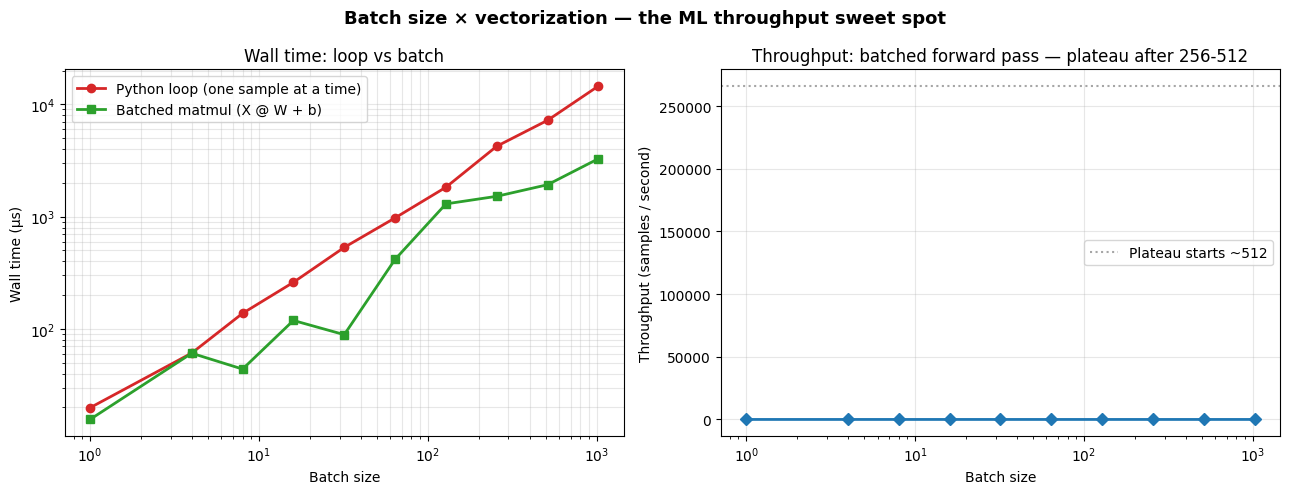


Insight: batched matmul time grows slowly (BLAS parallelism fills in).
Throughput increases near-linearly until ~256-512, then plateaus.
Beyond the plateau, you're just increasing memory pressure (larger batch = more VRAM).

Production rule: batch_size=1 inference is never acceptable in production.
Even on CPU: a batch of 32 costs ~2× what batch=1 costs, serving 32× more.
Find the plateau for your model — often 256-512 for CNNs, higher for Transformers.


In [12]:
import numpy as np
import timeit
import matplotlib.pyplot as plt

D_IN, D_OUT = 512, 256
rng = np.random.default_rng(0)
W   = rng.standard_normal((D_IN, D_OUT)).astype(np.float32)
b   = rng.standard_normal(D_OUT).astype(np.float32)

def forward_loop(samples):
    results = []
    for x in samples:
        results.append(x @ W + b)
    return np.stack(results)

def forward_batch(X):
    return X @ W + b

batch_sizes  = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
N            = 300
loop_μs      = []
batch_μs     = []
throughputs  = []

for bs in batch_sizes:
    X       = rng.standard_normal((bs, D_IN)).astype(np.float32)
    samples = [X[i] for i in range(bs)]

    t_loop  = timeit.timeit(lambda: forward_loop(samples),  number=N) / N
    t_batch = timeit.timeit(lambda: forward_batch(X),        number=N) / N

    loop_μs.append(t_loop * 1e6)
    batch_μs.append(t_batch * 1e6)
    throughputs.append(bs / t_batch)

# ── Table ──────────────────────────────────────────────────────
print(f"{'Batch':>6}  {'Loop (μs)':>10}  {'Batch (μs)':>11}  {'Speedup':>8}  {'Samples/s':>12}")
print("-" * 56)
for bs, tl, tb, sp in zip(batch_sizes, loop_μs, batch_μs,
                           [l/b for l,b in zip(loop_μs, batch_μs)]):
    tp = bs / (tb / 1e6)
    print(f"{bs:>6}  {tl:>10.1f}  {tb:>11.2f}  {sp:>7.1f}×  {tp:>12,.0f}")

# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.loglog(batch_sizes, loop_μs,   'o-', color='#d62728', linewidth=2,
           label='Python loop (one sample at a time)')
ax1.loglog(batch_sizes, batch_μs,  's-', color='#2ca02c', linewidth=2,
           label='Batched matmul (X @ W + b)')
ax1.set_xlabel("Batch size")
ax1.set_ylabel("Wall time (μs)")
ax1.set_title("Wall time: loop vs batch")
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

ax2.semilogx(batch_sizes, [t/1e6 for t in throughputs], 'D-',
             color='#1f77b4', linewidth=2)
ax2.set_xlabel("Batch size")
ax2.set_ylabel("Throughput (samples / second)")
ax2.set_title("Throughput: batched forward pass — plateau after 256-512")
ax2.axhline(throughputs[batch_sizes.index(512)], color='gray', linestyle=':', alpha=0.7,
            label='Plateau starts ~512')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Batch size × vectorization — the ML throughput sweet spot",
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print()
print("Insight: batched matmul time grows slowly (BLAS parallelism fills in).")
print("Throughput increases near-linearly until ~256-512, then plateaus.")
print("Beyond the plateau, you're just increasing memory pressure (larger batch = more VRAM).")
print()
print("Production rule: batch_size=1 inference is never acceptable in production.")
print("Even on CPU: a batch of 32 costs ~2× what batch=1 costs, serving 32× more.")
print("Find the plateau for your model — often 256-512 for CNNs, higher for Transformers.")


---
# Summary — HPP Ch 1: One-Page Reference


## The single rule

> **Find the bottleneck. Fix that. Re-measure. Repeat.**
> Profile before you optimize. Never guess.

---

## The 3-component mental model

| Component | Bottleneck symptom | Diagnostic |
|---|---|---|
| Computing units | High CPU/GPU utilization, slow math | `cProfile`, `line_profiler` |
| Memory | Cache thrashing, OOM, slow iteration | `memory_profiler`, `valgrind` |
| Communications | GPU idle (waiting for data), slow transfers | GPU utilization monitor, `nvtop` |

## Computing units

| Concept | Production rule |
|---|---|
| IPC × clock = throughput | Clock stalled → go wide: SIMD, multicore |
| Vectorization | NumPy/PyTorch do it; Python `for` loops don't |
| GIL | Threads serialize pure Python; `multiprocessing` or NumPy (GIL released) |
| Amdahl's law | Serial fraction caps speedup — profile to find it before adding workers |

## Memory hierarchy

| Concept | Production rule |
|---|---|
| Speed ↑ = capacity ↓ | Keep hot data in RAM; stream cold data with `DataLoader` |
| Sequential > random | Contiguous arrays; avoid pointer-chasing through Python lists |
| Python object tax | `list[float]` = 24 bytes/elem; `np.float32` = 4 bytes/elem |
| PCIe bottleneck | `.to(device)` once; `pin_memory=True`; large batches |

## Communications

| Concept | Production rule |
|---|---|
| Bus bandwidth | RAM (256 Gb/s) >> PCIe (128 Gb/s) >> network (1–100 Gb/s) |
| Data locality | Move data to the right tier once; minimize re-fetching |
| GPU transfers | Batch PCIe transfers; keep model on device; use `pin_memory` |

## Python VM overhead

| Killer | Impact | Fix |
|---|---|---|
| No auto-vectorization | 50–200× slower than C for math loops | NumPy, Numba, Cython |
| Dynamic types | Per-operation type lookup | Type-stable C extensions |
| Memory fragmentation | Cache misses per object access | Contiguous arrays |

## The 3-phase workflow

```
Make it work  →  Make it right  →  [ Profile ]  →  Make it fast
                     ↑                   ↑
              pytest + assert       cProfile +
              + ValueError          line_profiler
```

## ML connection map

| HPP Ch 1 concept | ML consequence |
|---|---|
| GIL | `DataLoader(num_workers=N)` uses processes; numpy-heavy transforms can use threads |
| Amdahl's law | `num_workers` ceiling set by serial collation fraction — profile first |
| Python object tax | Store data as `np.float32`; never `list[float]` for numerical data |
| Sequential memory | `(N, C, H, W)` contiguous; `.contiguous()` before `.view()` |
| PCIe bus | `pin_memory=True`; move model to device once; batch GPU operations |
| Vectorization | `model(batch)` >> `[model(x) for x in batch]` — always batch |
| 3-phase workflow | Prototype → test → `cProfile` → `line_profiler` → optimize one thing |

## What's next — Ch 2: Profiling to Find Bottlenecks

The Julia Set becomes the running example — a compute-heavy fractal that
makes profiling results dramatic and measurable.

Tools:
- `cProfile` + `pstats` — which function is the bottleneck?
- `line_profiler` (`@profile`) — which line is the bottleneck?
- `memory_profiler` — which line allocates the most?
- `pyinstrument` — low-overhead sampling profiler
- `dis` module (PNP Ch 57) — read the CPython bytecode directly

The mental model from Ch 1 tells you **what** to look for.
Ch 2 tools tell you **where** it is.
